In [0]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc,roc_curve
import matplotlib.pyplot as plt   
import seaborn as sns
%matplotlib inline 

In [0]:
#Read bank data from csv file
df_bank = pd.read_csv("bank.csv")

### 2. Drop the columns which are unique for all users like IDs (5 points)

In [0]:

df_bank = df_bank.drop(["RowNumber","CustomerId","Surname"], axis = 1)

### 3. Distinguish the feature and target set (5 points)

In [0]:
df_bank["Exited"].value_counts()

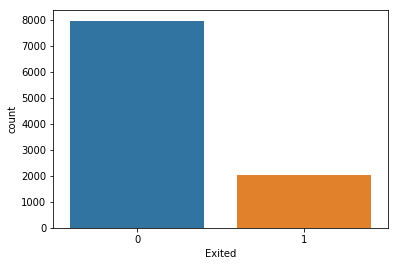

In [0]:
plot = sns.countplot(x = "Exited", data = df_bank)
plot.set_xticklabels(plot.get_xticklabels());

In [0]:
df_bank = pd.get_dummies(my_df,drop_first=True)

### 4. Divide the data set into Train and test sets

In [0]:

X = df_bank.drop(["Exited"], axis=1)

y = df_bank["Exited"]

In [0]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=7)

### 5. Normalize the train and test data (5 points)

In [0]:

from sklearn.preprocessing import StandardScaler

transformer = StandardScaler()
X_train = transformer.fit_transform(X_train)
X_test = transformer.transform(X_test)

### 6. Initialize & build the model (10 points)

In [0]:
#Import Tensorflow & Keras Library
import tensorflow as tf
import keras

Using TensorFlow backend.


In [0]:

bank_model = tf.keras.models.Sequential()

bank_model.add(tf.keras.layers.Dense(6,  activation='relu', input_shape=(11,)))

bank_model.add(tf.keras.layers.Dense(6,  activation='relu'))
bank_model.add( tf.keras.layers.Dense(1,activation='sigmoid', name='output'))

bank_model.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])

In [0]:
history =bank_model.fit(X_train, y_train,epochs=100,batch_size = 30,validation_data=(X_test, y_test) )

### 7. Optimize the model (Optional)


### Build the Model with Adam optimizer and early stop which help  for model to protect from overfitting

In [0]:

bankmodel1 = tf.keras.models.Sequential()

bankmodel1.add(tf.keras.layers.Dense(6,  activation='relu', input_shape=(11,)))

bankmodel1.add(tf.keras.layers.Dense(6,  activation='relu'))
bankmodel1.add( tf.keras.layers.Dense(1,activation='sigmoid', name='output'))

bankmodel1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [0]:
earlyStop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=5)

In [0]:
history =bankmodel1.fit(X_train, y_train, 
          validation_data=(X_train, y_train), 
          epochs=300,
          batch_size=32,
          callbacks=[earlyStop])

In [0]:
bankmodel1.summary()

Model: "sequential_4"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_8 (Dense)              (None, 6)                 72        
_________________________________________________________________
dense_9 (Dense)              (None, 6)                 42        
_________________________________________________________________
output (Dense)               (None, 1)                 7         
Total params: 121
Trainable params: 121
Non-trainable params: 0
_________________________________________________________________


### 8. Predict the results using 0.5 as a threshold (Optional)


In [0]:
y_model_pred = bankmodel1.predict(X_test)
y_pred = (y_model_pred > 0.5) 

### 9. Print the Accuracy score and confusion matrix (5 points)

In [0]:
cm = confusion_matrix(y_test, y_pred)
print("ANN Model Confussion Matrix : \n {0}\n".format(cm))

TN, FP,FN, TP = cm.ravel()
Result=pd.DataFrame(index=["TrueNegatives","FalsePositives","FalseNegatives","TruePositives","Accuracy", "Recall", "Precision", "F1_Score"])

ANN_ModelResult=[TN,FP,FN,TP,accuracy_score(y_test, y_pred), 
                   recall_score(y_test, y_pred), 
                   precision_score(y_test, y_pred),
                   f1_score(y_test, y_pred)]

Result["ANN_Model_Result"]=ANN_ModelResult

print("ANN Model Result : \n\n {0}\n".format(Result))

ANN Model Confussion Matrix : 
 [[2289  106]
 [ 306  299]]

ANN Model Result : 

                 ANN_Model_Result
TrueNegatives        2289.000000
FalsePositives        106.000000
FalseNegatives        306.000000
TruePositives         299.000000
Accuracy                0.862667
Recall                  0.494215
Precision               0.738272
F1_Score                0.592079

